# Cross-region classifier comparison

Loads per-subject predictions from every (model x region x seed) cell, runs the 7
pre-registered H1/H2/H3 contrasts with paired DeLong's test, applies Holm-Bonferroni
correction, and emits forest plots + heatmap + contrast CSV.

**Run order**
1. Stage 1 (this notebook on mock data) - validates the statistical pipeline end-to-end.
2. Stages 2-4 (separate notebooks) - train GAAE / LogReg / GEC / GELSTM per region+seed.
3. Stage 5 (this notebook on real predictions) - load real parquets, regenerate plots.

Same subjects, same splits across every cell - paired tests are the entire point.

In [1]:
# === Papermill parameters (injected by run_experiment.py) ===
# Safe interactive defaults: None keeps the original Jupyter behaviour
# (interactive checkpoint/threshold prompts, JSON-config loading).
EXPERIMENT_ID = None
MODE = None
MODEL = None
DATASET = None
SEED = 42
GAAE_CHECKPOINT_PATH = None   # None -> interactive checkpoint picker
THRESHOLD_MODE = None         # None -> interactive prompt; else youden | best-f1 | fixed
FIXED_THRESHOLD = None        # required when THRESHOLD_MODE is fixed
WANDB_ENABLED = True          # W&B logging is on by default
OUTPUT_DIR = None             # defaults to outputs/<experiment-id>/ when run standalone
RESOLVED_CONFIG = None        # merged hyperparameter dict; overrides on-disk JSON when set
RUN_DIR = None                # set by the runner: where run_summary.json / artifacts go
RUN_NAME = None               # set by the runner: the W&B run name


In [2]:
# Parameters
EXPERIMENT_ID = "comparison-cross-region-classifier"
MODE = "comparison"
MODEL = "multi"
DATASET = "DELCODE_MULTI_REGION"
SEED = 42
GAAE_CHECKPOINT_PATH = None
THRESHOLD_MODE = None
FIXED_THRESHOLD = None
WANDB_ENABLED = True
OUTPUT_DIR = "outputs/comparison-cross-region-classifier"
RESOLVED_CONFIG = {}
RUN_DIR = "/mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/comparison-cross-region-classifier/runs/fallen-wildflower-1-nogit-2026-06-25_11-06-16"
RUN_NAME = "fallen-wildflower-1-nogit-2026-06-25_11-06-16"


In [3]:
import sys
from pathlib import Path
REPO_ROOT = Path("/mnt/e/fyassine/ad-early-detection")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [4]:
from SHARED.seeding import set_seed, make_rng
SEED = 42
set_seed(SEED)
rng = make_rng(SEED)

In [5]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score

from CLASSIFIER.common.comparison import (
    holm_correction,
    paired_bootstrap_ci,
    paired_delong_test,
)
from CLASSIFIER.common.contrasts import CONTRASTS, regions_referenced

/tmp/ipykernel_1951411/2053048743.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Configuration

Set `USE_MOCK = True` to validate the pipeline against synthetic predictions before any model is trained. Set `USE_MOCK = False` once parquets exist under `CLASSIFIER/outputs/<model>-<region>-seed<S>/predictions_test.parquet`.

In [6]:
USE_MOCK = True

MODELS = ["logreg", "gec", "gelstm"]
REGIONS = list(regions_referenced())
SEEDS = [42, 43, 44]
N_BOOT = 1000
ALPHA = 0.05

REPO_ROOT = Path("/mnt/e/fyassine/ad-early-detection")
OUTPUTS_DIR = REPO_ROOT / "CLASSIFIER" / "outputs"
RESULTS_DIR = REPO_ROOT / "CLASSIFIER" / "notebooks" / "COMPARISON" / "_results"
RESULTS_DIR.mkdir(exist_ok=True)

## Load predictions

Every cell is a parquet with columns `subject_id, prob, pred, label, seed`. The DELCODE shared-split guarantee means `subject_id` is identical across cells of the same seed - we align by joining on `(subject_id, seed)`.

In [7]:
def _mock_labels(seed: int, n_test: int = 47) -> np.ndarray:
    """Labels depend ONLY on seed (paired-test invariant: identical across models/regions)."""
    return np.random.default_rng(0xCAFE0000 + seed).integers(0, 2, size=n_test)


def _mock_predictions(region: str, model: str, seed: int, n_test: int = 47) -> pd.DataFrame:
    """Synthetic predictions with region-dependent AUC for pipeline validation.

    Labels come from `_mock_labels(seed)` so they are identical across every
    (model, region) cell of the same seed - the same invariant real DELCODE splits
    guarantee. Only the predictions vary across (model, region).
    """
    labels = _mock_labels(seed, n_test)
    r_seed = (hash((region, model, seed)) & 0xFFFFFFFF)
    rng_local = np.random.default_rng(r_seed)
    region_aucs = {
        "wholebrain":            0.78,
        "dmn":                   0.75,
        "hippo":                 0.68,
        "limbic":                0.66,
        "dan":                   0.62,
        "dmn-hippo":             0.80,
        "dmn-limbic":            0.77,
        "dmn-hippo-limbic":      0.82,
        "dmn-hippo-limbic-dan":  0.80,
    }
    model_offsets = {"logreg": -0.04, "gec": 0.0, "gelstm": 0.02}
    target_auc = region_aucs.get(region, 0.70) + model_offsets.get(model, 0.0)
    shift = (2.0 * target_auc - 1.0) * 2.0
    probs = rng_local.normal(size=n_test) + labels * shift
    probs = 1.0 / (1.0 + np.exp(-probs))
    return pd.DataFrame({
        "subject_id": [f"sub-{i:04d}" for i in range(n_test)],
        "prob": probs,
        "pred": (probs > 0.5).astype(int),
        "label": labels,
        "seed": seed,
    })


def load_cell(model: str, region: str, seed: int) -> pd.DataFrame:
    if USE_MOCK:
        return _mock_predictions(region, model, seed)
    path = OUTPUTS_DIR / f"{model}-{region}-seed{seed}" / "predictions_test.parquet"
    if not path.exists():
        raise FileNotFoundError(f"Missing predictions: {path}")
    return pd.read_parquet(path)


cells: dict[tuple[str, str, int], pd.DataFrame] = {}
for m in MODELS:
    for r in REGIONS:
        for s in SEEDS:
            cells[(m, r, s)] = load_cell(m, r, s)
print(f"Loaded {len(cells)} cells ({len(MODELS)} models x {len(REGIONS)} regions x {len(SEEDS)} seeds)")

Loaded 63 cells (3 models x 7 regions x 3 seeds)


## Per-cell metrics with bootstrap CIs

In [8]:
rows = []
for (m, r, s), df in cells.items():
    auc = roc_auc_score(df["label"], df["prob"])
    f1 = f1_score(df["label"], df["pred"])
    rows.append({"model": m, "region": r, "seed": s, "auc": auc, "f1": f1, "n": len(df)})

per_cell = pd.DataFrame(rows)
per_cell_summary = (
    per_cell.groupby(["model", "region"])
    .agg(auc_mean=("auc", "mean"), auc_std=("auc", "std"),
         f1_mean=("f1", "mean"), f1_std=("f1", "std"))
    .reset_index()
)
per_cell_summary.to_csv(RESULTS_DIR / "per_cell_summary.csv", index=False)
per_cell_summary

,model,region,auc_mean,auc_std,f1_mean,f1_std
0,gec,dmn,0.792508,0.064179,0.702204,0.073651
1,gec,dmn-hippo,0.809413,0.035969,0.711091,0.111651
2,gec,dmn-hippo-limbic,0.826424,0.038559,0.749071,0.097798
3,gec,dmn-hippo-limbic-dan,0.772592,0.036036,0.668698,0.101721
4,gec,dmn-limbic,0.779446,0.035385,0.690972,0.080911
5,gec,hippo,0.738808,0.137990,0.685674,0.111251
6,gec,wholebrain,0.755543,0.034526,0.698182,0.088477
7,gelstm,dmn,0.793545,0.035340,0.698605,0.035509
8,gelstm,dmn-hippo,0.845041,0.023519,0.747860,0.060922
9,gelstm,dmn-hippo-limbic,0.861294,0.098221,0.704719,0.145702


## Pre-registered contrasts (paired DeLong + Holm)

For each model, pool predictions across seeds (concatenate, since same test subjects in each seed), then run DeLong's test on the pooled predictions. Holm-correct across the 7 contrasts within each model.

In [9]:
def pool_across_seeds(model: str, region: str) -> pd.DataFrame:
    """Concat predictions across seeds. Same subjects, so this gives 3x47 paired rows."""
    return pd.concat([cells[(model, region, s)] for s in SEEDS], ignore_index=True)


contrast_rows = []
for model in MODELS:
    pvals = []
    raw = []
    for c in CONTRASTS:
        df_a = pool_across_seeds(model, c.region_a)
        df_b = pool_across_seeds(model, c.region_b)
        # Sanity: pairing is by (subject_id, seed) order - identical labels expected.
        assert np.array_equal(df_a["label"].values, df_b["label"].values), (
            f"Label mismatch between {c.region_a} and {c.region_b} for model {model}"
        )
        delta, lo, hi, p = paired_delong_test(
            df_a["prob"].values, df_b["prob"].values, df_a["label"].values, alpha=ALPHA,
        )
        raw.append({
            "model": model, "contrast": c.name, "hypothesis": c.hypothesis,
            "region_a": c.region_a, "region_b": c.region_b,
            "delta_auc": delta, "ci_lo": lo, "ci_hi": hi, "p_raw": p,
        })
        pvals.append(p)
    rejected, adj_p = holm_correction(np.array(pvals), alpha=ALPHA)
    for i, row in enumerate(raw):
        row["p_holm"] = float(adj_p[i])
        row["rejected"] = bool(rejected[i])
        contrast_rows.append(row)

contrast_df = pd.DataFrame(contrast_rows)
contrast_df.to_csv(RESULTS_DIR / "contrast_table.csv", index=False)
contrast_df

,model,contrast,hypothesis,region_a,region_b,delta_auc,ci_lo,ci_hi,p_raw,p_holm,rejected
0,logreg,H1_wholebrain_vs_dmn,H1,wholebrain,dmn,-0.062222,-0.178327,0.053882,0.293545,1.000000,False
1,logreg,H1_wholebrain_vs_best_memory,H1,wholebrain,dmn-hippo-limbic,-0.008485,-0.124015,0.107045,0.885544,1.000000,False
2,logreg,H2_dmn_vs_dmn_hippo,H2,dmn,dmn-hippo,0.043030,-0.071184,0.157245,0.460261,1.000000,False
3,logreg,H2_dmn_vs_dmn_limbic,H2,dmn,dmn-limbic,0.065455,-0.050763,0.181672,0.269653,1.000000,False
4,logreg,H2_dmn_hippo_vs_dmn_hippo_limbic,H2,dmn-hippo,dmn-hippo-limbic,0.010707,-0.103129,0.124543,0.853740,1.000000,False
5,logreg,H3_memory_vs_memory_plus_dan,H3,dmn-hippo-limbic,dmn-hippo-limbic-dan,-0.005455,-0.116441,0.105532,0.923263,1.000000,False
6,logreg,SANITY_hippo_vs_dmn_hippo,sanity,hippo,dmn-hippo,-0.105657,-0.229246,0.017933,0.093822,0.656751,False
7,gec,H1_wholebrain_vs_dmn,H1,wholebrain,dmn,-0.024242,-0.126050,0.077565,0.640709,1.000000,False
8,gec,H1_wholebrain_vs_best_memory,H1,wholebrain,dmn-hippo-limbic,-0.054949,-0.160448,0.050549,0.307323,1.000000,False
9,gec,H2_dmn_vs_dmn_hippo,H2,dmn,dmn-hippo,-0.032121,-0.132870,0.068628,0.532047,1.000000,False


## Bootstrap CIs for F1 / sensitivity (non-AUC metrics)

DeLong is AUC-only. For F1 and sensitivity contrasts use paired bootstrap. Run on demand - cached when expensive.

In [10]:
def _f1_at_05(y_true, y_score):
    return f1_score(y_true, (np.asarray(y_score) > 0.5).astype(int))


f1_rows = []
for model in MODELS:
    for c in CONTRASTS[:2]:  # demo: first 2 contrasts. Extend when needed.
        df_a = pool_across_seeds(model, c.region_a)
        df_b = pool_across_seeds(model, c.region_b)
        delta, lo, hi = paired_bootstrap_ci(
            df_a["prob"].values, df_b["prob"].values, df_a["label"].values,
            _f1_at_05, n_boot=N_BOOT, alpha=ALPHA, rng=make_rng(SEED),
        )
        f1_rows.append({"model": model, "contrast": c.name,
                        "delta_f1": delta, "ci_lo": lo, "ci_hi": hi})

f1_df = pd.DataFrame(f1_rows)
f1_df

,model,contrast,delta_f1,ci_lo,ci_hi
0,logreg,H1_wholebrain_vs_dmn,-0.016981,-0.098148,0.063418
1,logreg,H1_wholebrain_vs_best_memory,0.016456,-0.063815,0.096801
2,gec,H1_wholebrain_vs_dmn,0.000497,-0.065366,0.074147
3,gec,H1_wholebrain_vs_best_memory,-0.049193,-0.114776,0.022607
4,gelstm,H1_wholebrain_vs_dmn,0.051788,-0.035601,0.142889
5,gelstm,H1_wholebrain_vs_best_memory,0.037177,-0.026101,0.101644


## Forest plot - AUC per (model, region)

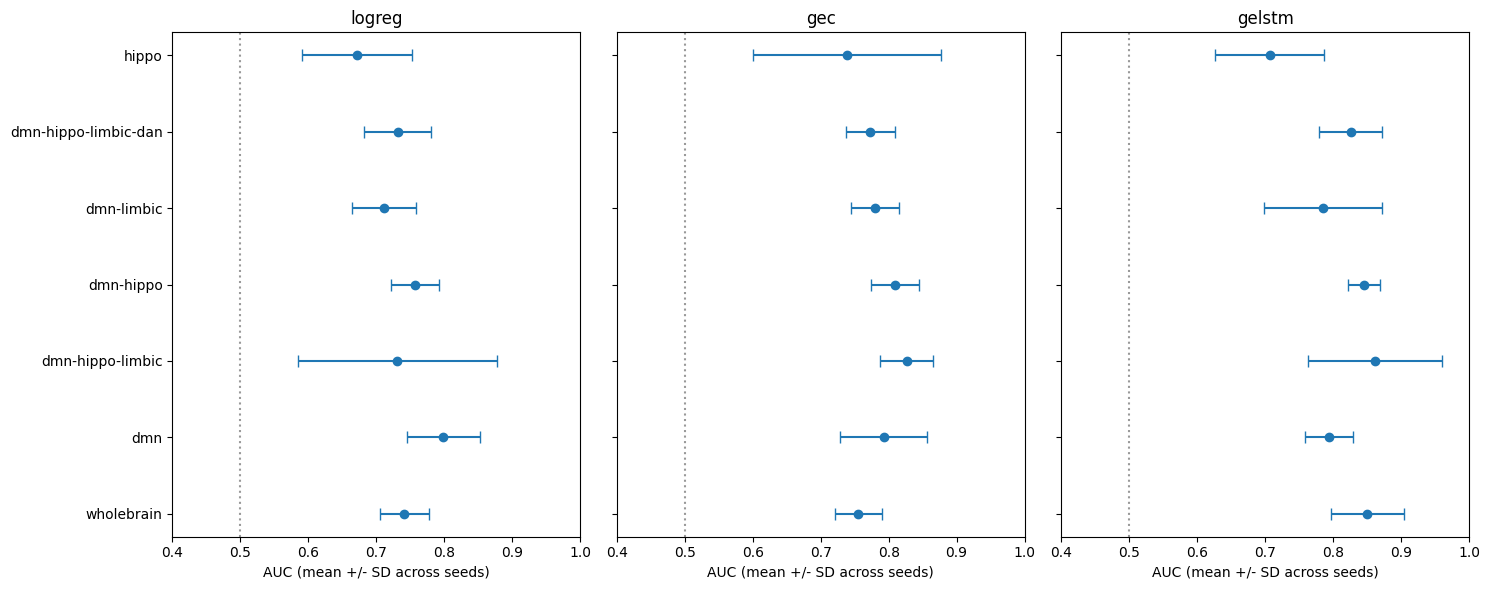

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 6), sharey=True)
if len(MODELS) == 1:
    axes = [axes]
for ax, model in zip(axes, MODELS):
    sub = per_cell_summary[per_cell_summary["model"] == model].copy()
    sub = sub.set_index("region").reindex(REGIONS)
    y = np.arange(len(REGIONS))
    ax.errorbar(sub["auc_mean"], y, xerr=sub["auc_std"], fmt="o", capsize=4)
    ax.set_yticks(y); ax.set_yticklabels(REGIONS)
    ax.axvline(0.5, color="k", linestyle=":", alpha=0.4)
    ax.set_title(model); ax.set_xlabel("AUC (mean +/- SD across seeds)")
    ax.set_xlim(0.4, 1.0)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "forest_auc.png", dpi=150)
plt.show()

## Heatmap - region x model AUC (supplementary)

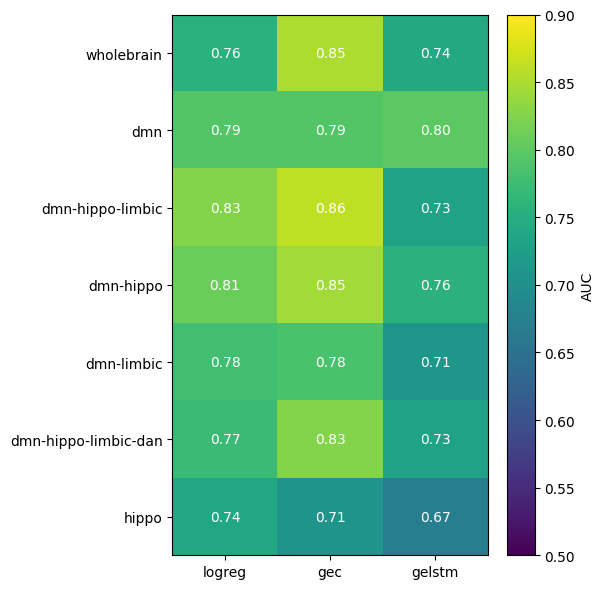

In [12]:
pivot = per_cell_summary.pivot(index="region", columns="model", values="auc_mean").reindex(REGIONS)
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(pivot.values, cmap="viridis", vmin=0.5, vmax=0.9, aspect="auto")
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS)
ax.set_yticks(range(len(REGIONS))); ax.set_yticklabels(REGIONS)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", color="white")
fig.colorbar(im, ax=ax, label="AUC")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "heatmap_auc.png", dpi=150)
plt.show()

## Summary

- `_results/per_cell_summary.csv` - mean +/- SD AUC and F1 per (model, region) across seeds.
- `_results/contrast_table.csv` - 7 pre-registered contrasts x {model}, with raw + Holm-adjusted p, 95% CI for delta-AUC.
- `_results/forest_auc.png`, `_results/heatmap_auc.png` - figures.

Switch `USE_MOCK = False` once real predictions exist under `CLASSIFIER/outputs/<model>-<region>-seed<S>/`.